In [1]:
from datasets import load_dataset
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

train_dataset = load_dataset("cardiffnlp/tweet_eval", 'sentiment', split='train')
test_dataset = load_dataset("cardiffnlp/tweet_eval", 'sentiment', split='test')

columns_to_drop = [col for col in train_dataset.column_names if col not in ['text', 'label']]

# Tokenize
tokenizer = RobertaTokenizer.from_pretrained('FacebookAI/roberta-base')
def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, padding='max_length', max_length=128)

/home/lava/Documents/ML/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from datasets import ClassLabel, Value

train_dataset=train_dataset.cast_column('label', Value('float64'))
test_dataset=test_dataset.cast_column('label', Value('float64'))

In [3]:
type(train_dataset['label'][0])

float

In [4]:
train_data = train_dataset.map(tokenize, batched=True)
tokenized_holdout = train_dataset.map(tokenize, batched=True)
tokenized_holdout = tokenized_holdout.train_test_split(test_size=.5, seed=42)
test_data = tokenized_holdout['train']
val_data = tokenized_holdout['test']

In [5]:
val_data.info

DatasetInfo(description='', citation='', homepage='', license='', features={'text': Value('string'), 'label': Value('float64'), 'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8'))}, post_processed=None, supervised_keys=None, builder_name='parquet', dataset_name='tweet_eval', config_name='sentiment', version=0.0.0, splits={'train': SplitInfo(name='train', num_bytes=5430824, num_examples=45615, shard_lengths=None, original_shard_lengths=None, dataset_name='tweet_eval'), 'test': SplitInfo(name='test', num_bytes=1281076, num_examples=12284, shard_lengths=None, original_shard_lengths=None, dataset_name='tweet_eval'), 'validation': SplitInfo(name='validation', num_bytes=239334, num_examples=2000, shard_lengths=None, original_shard_lengths=None, dataset_name='tweet_eval')}, download_checksums={'hf://datasets/cardiffnlp/tweet_eval@b3a375baf0f409c77e6bc7aa35102b7b3534f8be/sentiment/train-00000-of-00001.parquet': {'num_bytes': 3781982, 'checksum': None}, 'hf://datasets/cardi

In [6]:
# Format for PyTorch
columns_to_keep = ['input_ids', 'attention_mask', 'label']
train_data.set_format(type='torch', columns=columns_to_keep)
val_data.set_format(type='torch', columns=columns_to_keep)
test_data.set_format(type='torch', columns=columns_to_keep)

In [7]:
test_data.info

DatasetInfo(description='', citation='', homepage='', license='', features={'text': Value('string'), 'label': Value('float64'), 'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8'))}, post_processed=None, supervised_keys=None, builder_name='parquet', dataset_name='tweet_eval', config_name='sentiment', version=0.0.0, splits={'train': SplitInfo(name='train', num_bytes=5430824, num_examples=45615, shard_lengths=None, original_shard_lengths=None, dataset_name='tweet_eval'), 'test': SplitInfo(name='test', num_bytes=1281076, num_examples=12284, shard_lengths=None, original_shard_lengths=None, dataset_name='tweet_eval'), 'validation': SplitInfo(name='validation', num_bytes=239334, num_examples=2000, shard_lengths=None, original_shard_lengths=None, dataset_name='tweet_eval')}, download_checksums={'hf://datasets/cardiffnlp/tweet_eval@b3a375baf0f409c77e6bc7aa35102b7b3534f8be/sentiment/train-00000-of-00001.parquet': {'num_bytes': 3781982, 'checksum': None}, 'hf://datasets/cardi

In [8]:
model = RobertaForSequenceClassification.from_pretrained('FacebookAI/roberta-base', num_labels=1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

training_args = TrainingArguments(
    output_dir="./roberta_sentiment_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    learning_rate=5e-5,
    per_device_train_batch_size=64, # Optimized for high RAM
    per_device_eval_batch_size=64,
    num_train_epochs=100,            # High epoch limit, protected by Early Stopping
    weight_decay=0.01,
    bf16=True,                      # High precision/speed math
    save_total_limit=2,
    dataloader_num_workers=8        # CPU parallel processing
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=val_data,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

trainer.train()

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 6032.68it/s]
RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss
1,0.312323,0.188422
2,0.226911,0.173071
3,0.157616,0.102866
4,0.130050,0.067900
5,0.096646,0.052739
6,0.078488,0.054915
7,0.070747,0.038438
8,0.056849,0.038917
9,0.052575,0.029573
10,0.045745,0.032524


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.34it/s]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la

TrainOutput(global_step=10695, training_loss=0.09024619057447122, metrics={'train_runtime': 2124.8973, 'train_samples_per_second': 2146.692, 'train_steps_per_second': 33.555, 'total_flos': 4.50063863656128e+16, 'train_loss': 0.09024619057447122, 'epoch': 15.0})

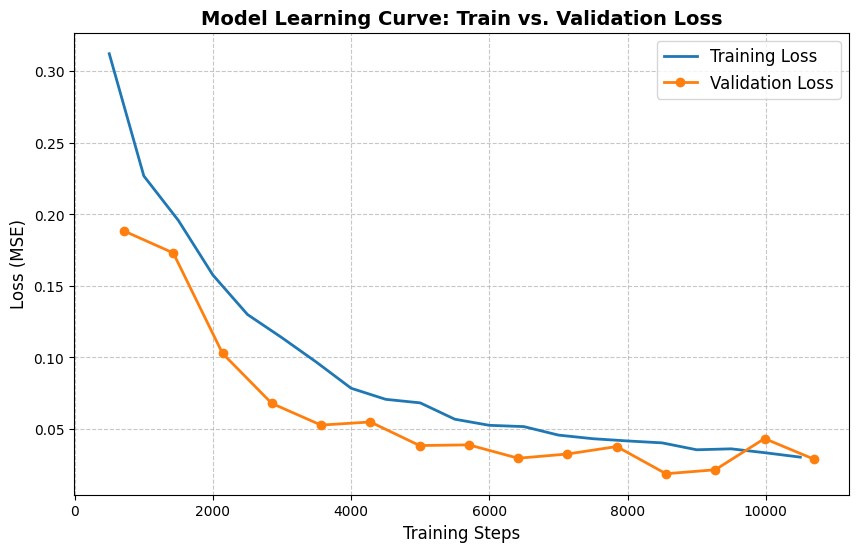

In [9]:
# Extract loss logs
logs = trainer.state.log_history
train_steps = [log['step'] for log in logs if 'loss' in log]
train_loss = [log['loss'] for log in logs if 'loss' in log]
eval_steps = [log['step'] for log in logs if 'eval_loss' in log]
eval_loss = [log['eval_loss'] for log in logs if 'eval_loss' in log]

# Plot Learning Curve
plt.figure(figsize=(10, 6))
plt.plot(train_steps, train_loss, label='Training Loss', color='#1f77b4', linewidth=2)
plt.plot(eval_steps, eval_loss, label='Validation Loss', color='#ff7f0e', linewidth=2, marker='o')
plt.grid(True, linestyle='--', alpha=0.7)
plt.title('Model Learning Curve: Train vs. Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Training Steps', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.legend(fontsize=12)
plt.show()

In [10]:
# Calculate Final Test MSE
pred = trainer.predict(test_data)
y_pred = pred.predictions.flatten()
y_true = pred.label_ids
mse = np.mean((y_true - y_pred) ** 2)
print(f"Final Test Mean Squared Error: {mse:.4f}")

Final Test Mean Squared Error: 0.0179


In [11]:
model_dir = "./roberta_model"
trainer.save_model(model_dir)
tokenizer.save_pretrained(model_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.35it/s]


('./roberta_model/tokenizer_config.json', './roberta_model/tokenizer.json')